In [1]:
import numpy as np
import pandas as pd
import os
import torch as ts
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns


In [2]:
class LSTMCell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.Wf=nn.Linear(input_size+hidden_size,hidden_size)
        self.Wi=nn.Linear(input_size+hidden_size,hidden_size)
        self.Wg=nn.Linear(input_size+hidden_size,hidden_size)
        self.Wo=nn.Linear(input_size+hidden_size,hidden_size)

    def forward(self,x,h_prev,c_prev):
        combined=ts.cat([h_prev,x],dim=1)
        f=ts.sigmoid(self.Wf(combined))
        i=ts.sigmoid(self.Wi(combined))
        g=ts.tanh(self.Wg(combined))
        o=ts.sigmoid(self.Wo(combined))
        c_new=f*c_prev+i*g
        h_new=o*ts.tanh(c_new)
        return h_new,c_new

In [3]:
class LSTMStacked(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.lstm1=LSTMCell(input_size,hidden_size)
        self.lstm2=LSTMCell(hidden_size,hidden_size)
        self.hidden_size=hidden_size

    def forward(self,x):
        batch_size=x.size(0)
        seq_len=x.size(1)

        h1=ts.zeros(batch_size,self.hidden_size)
        c1=ts.zeros(batch_size,self.hidden_size)
        h2=ts.zeros(batch_size,self.hidden_size)
        c2=ts.zeros(batch_size,self.hidden_size)

        for t in range(seq_len):
            x_t=x[:,t,:]

            h1,c1=self.lstm1(x_t,h1,c1)
            h2,c2=self.lstm2(h1,h2,c2)

        return h2

In [4]:
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.lstm=LSTMStacked(input_size,hidden_size)
        self.fc=nn.Linear(hidden_size,12)

    def forward(self,x):
        out=self.lstm(x)
        out=self.fc(out)
        return out

model=LSTMModel(input_size=14,hidden_size=64)

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/jena_climate_2009_2016.csv")

df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)
df = df.sort_values("Date Time")

# Converting 10-minute data to hourly data
hourly_df = (
    df.set_index("Date Time")
      .resample("1h")
      .mean(numeric_only=True)
      .dropna()
      .reset_index()
)

features = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

# Use hourly data instead of original data
data = hourly_df[features]

n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(
    len(train_data),
    len(val_data),
    len(test_data)
)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

49028 10506 10507


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:
def create_sequences(data, seq_len=72, future=12):
    X = []
    y = []
    for i in range(len(data)-seq_len-future):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len : i+seq_len+future, 1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

print("X train:",X_train.shape)
print("y train:",y_train.shape)

X train: (48944, 72, 14)
y train: (48944, 12)


In [11]:
from torch.utils.data import DataLoader,random_split,TensorDataset
import torch.nn as nn

X_train = ts.tensor(X_train, dtype=ts.float32)
y_train = ts.tensor(y_train, dtype=ts.float32)
X_val = ts.tensor(X_val, dtype=ts.float32)
y_val = ts.tensor(y_val, dtype=ts.float32)
X_test = ts.tensor(X_test, dtype=ts.float32)
y_test = ts.tensor(y_test, dtype=ts.float32)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [12]:
import torch.nn as nn
criterion=nn.MSELoss()
optimizer=ts.optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-5)
scheduler=ts.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)
num_epochs=10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    batchloss=0
    for X_batch,y_batch in train_loader:

        optimizer.zero_grad()

        y_batch_pred=model(X_batch)

        l=criterion(y_batch_pred,y_batch)

        l.backward()

        optimizer.step()

        batchloss+=l.item()


    model.eval()
    val_loss=0

    with ts.no_grad():
        for X_batch,y_batch in val_loader:

            y_batch_pred=model(X_batch)

            val_loss+=criterion(y_batch_pred,y_batch).item()


    scheduler.step()

    batchloss/=len(train_loader)
    train_losses.append(batchloss)
    val_losses.append((val_loss/len(val_loader)))
    print(f'Epoch {epoch+1}/{num_epochs} Train Loss: {batchloss:.4f} Val Loss: {val_loss/len(val_loader):.4f}')

Epoch 1/10 Train Loss: 0.1163 Val Loss: 0.0629
Epoch 2/10 Train Loss: 0.0541 Val Loss: 0.0561
Epoch 3/10 Train Loss: 0.0487 Val Loss: 0.0542
Epoch 4/10 Train Loss: 0.0460 Val Loss: 0.0538
Epoch 5/10 Train Loss: 0.0435 Val Loss: 0.0513
Epoch 6/10 Train Loss: 0.0416 Val Loss: 0.0506
Epoch 7/10 Train Loss: 0.0397 Val Loss: 0.0506
Epoch 8/10 Train Loss: 0.0382 Val Loss: 0.0493
Epoch 9/10 Train Loss: 0.0371 Val Loss: 0.0495
Epoch 10/10 Train Loss: 0.0364 Val Loss: 0.0491


In [13]:
model.eval()
test_loss = 0
preds = []
actuals = []

with ts.no_grad():
    for X_batch,y_batch in test_loader:

        y_pred = model(X_batch)
        loss = criterion(y_pred,y_batch)
        test_loss += loss.item()

        preds.extend(y_pred.numpy())
        actuals.extend(y_batch.numpy())

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0442


In [14]:
preds = np.array(preds)
actuals = np.array(actuals)

def inverse_transform_temp(values, scaler, temp_col_idx=1, n_features=14):
    dummy = np.zeros((values.shape[0]*values.shape[1], n_features))
    dummy[:, temp_col_idx] = values.flatten()
    inv = scaler.inverse_transform(dummy)[:, temp_col_idx]
    return inv.reshape(values.shape)

preds_celsius = inverse_transform_temp(preds, scaler)
actuals_celsius = inverse_transform_temp(actuals, scaler)

mae = np.mean(np.abs(preds_celsius - actuals_celsius))
rmse = np.sqrt(np.mean((preds_celsius - actuals_celsius)**2))
print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")

MAE: 1.340 °C
RMSE: 1.818 °C


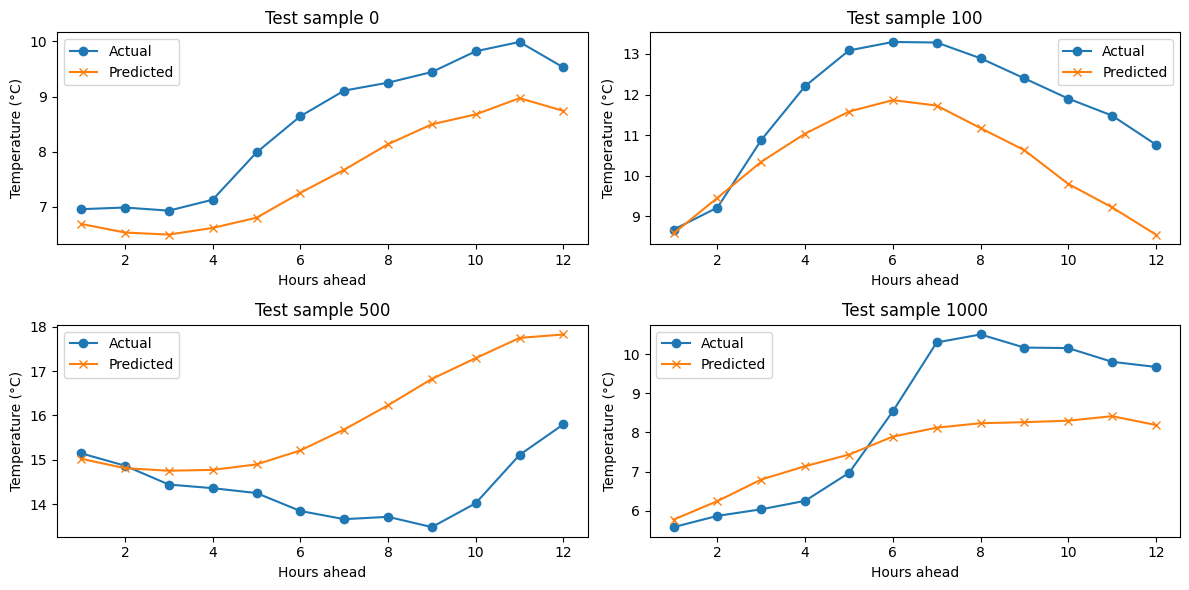

In [15]:
plt.figure(figsize=(12, 6))
sample_indices = [0, 100, 500, 1000]  # picking rand

for idx, i in enumerate(sample_indices):
    plt.subplot(2, 2, idx+1)
    plt.plot(range(1, 13), actuals_celsius[i], label='Actual', marker='o')
    plt.plot(range(1, 13), preds_celsius[i], label='Predicted', marker='x')
    plt.xlabel('Hours ahead')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Test sample {i}')
    plt.legend()

plt.tight_layout()
plt.savefig('lstm_predictions.png')
plt.show()


              precision    recall  f1-score   support

        down       0.81      0.86      0.84      4915
      stable       0.20      0.19      0.20       955
          up       0.84      0.80      0.82      4553

    accuracy                           0.77     10423
   macro avg       0.62      0.62      0.62     10423
weighted avg       0.77      0.77      0.77     10423



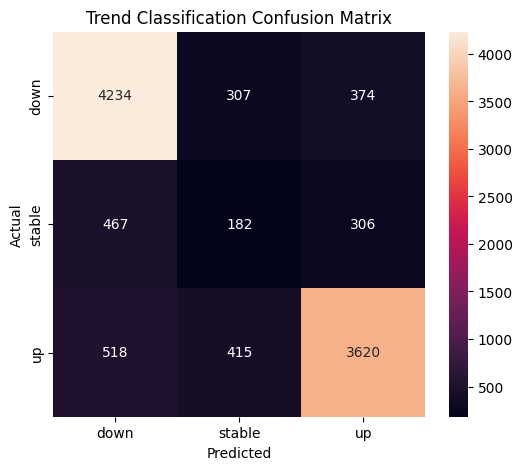

In [16]:
def to_trend_classes(values, threshold=0.5):
    diff = values[:, -1] - values[:, 0]   # change from hour 1 to hour 12
    classes = np.where(diff > threshold, 2, np.where(diff < -threshold, 0, 1))  # 0=down,1=stable,2=up
    return classes

pred_classes = to_trend_classes(preds_celsius)
actual_classes = to_trend_classes(actuals_celsius)

print(classification_report(actual_classes, pred_classes, target_names=['down','stable','up']))

cm = confusion_matrix(actual_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['down','stable','up'], yticklabels=['down','stable','up'])
plt.title('Trend Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('lstm_confusion_matrix.png')
plt.show()